In [ ]:
!pip install astronn tensorflow opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 77.3 MB/s eta 0:00:00


In [ ]:
#What is happening:

#astronn → gives Galaxy10 dataset

#tensorflow → deep learning framework

#opencv-python → image resizing

In [ ]:
from astroNN.datasets import galaxy10sdss

X, y = galaxy10sdss.load_data()

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

#The Galaxy10 SDSS dataset was loaded programmatically using the astroNN library

Galaxy10.h5:  99%|█████████▊| 208M/210M [00:07<00:00, 33.7MB/s]

Downloaded Galaxy10 successfully to /root/.astroNN/datasets/Galaxy10.h5


Galaxy10.h5: 210MB [00:07, 27.4MB/s]                           


Images shape: (21785, 69, 69, 3)
Labels shape: (21785,)


In [ ]:
'''our project requirement:
Spiral / Elliptical / Irregular

Galaxy10 gives 10 fine-grained classes

So we merge related classes'''

'our project requirement:\nSpiral / Elliptical / Irregular\n\nGalaxy10 gives 10 fine-grained classes\n\nSo we merge related classes'

In [ ]:
import numpy as np

def remap_labels(y):
    new_labels = []
    for label in y:
        if label in [1, 2, 3]:
            new_labels.append(0)  # Elliptical
        elif label in [7, 8, 9]:
            new_labels.append(1)  # Spiral
        else:
            new_labels.append(2)  # Irregular
    return np.array(new_labels)

y_new = remap_labels(y)

# Class names (IMPORTANT for later UI)
classes = ["Elliptical", "Spiral", "Irregular"]

# Check distribution
unique, counts = np.unique(y_new, return_counts=True)
dict(zip(unique, counts))


{np.int64(0): np.int64(13638),
 np.int64(1): np.int64(2546),
 np.int64(2): np.int64(5601)}

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_new, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.33, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

#Dataset split is correct (70 / 20 / 10 approx)

Train: (15249, 69, 69, 3)
Validation: (4379, 69, 69, 3)
Test: (2157, 69, 69, 3)


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input

def resnet_generator(X, y, batch_size=16, shuffle=True):
    num_samples = len(X)
    indices = np.arange(num_samples)

    while True:
        if shuffle:
            np.random.shuffle(indices)

        for start in range(0, num_samples, batch_size):
            end = start + batch_size
            batch_idx = indices[start:end]

            batch_images = []
            batch_labels = y[batch_idx]

            for img in X[batch_idx]:
                img = cv2.resize(img, (224, 224))
                batch_images.append(img)

            batch_images = np.array(batch_images, dtype=np.float32)
            batch_images = preprocess_input(batch_images)

            yield batch_images, batch_labels


In [ ]:
#Load ResNet50 (THIS IS THE CNN)

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model


In [ ]:
# Load pre-trained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ResNet layers
base_model.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
batch_size = 16

train_gen = resnet_generator(X_train, y_train, batch_size)
val_gen   = resnet_generator(X_val, y_val, batch_size, shuffle=False)

history = model.fit(
    train_gen,
    steps_per_epoch=len(X_train)//batch_size,
    validation_data=val_gen,
    validation_steps=len(X_val)//batch_size,
    epochs=10
)


Epoch 1/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 70s 61ms/step - accuracy: 0.7921 - loss: 0.5158 - val_accuracy: 0.8416 - val_loss: 0.3856
Epoch 2/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 61s 61ms/step - accuracy: 0.8428 - loss: 0.3780 - val_accuracy: 0.8544 - val_loss: 0.3629
Epoch 3/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 85s 89ms/step - accuracy: 0.8543 - loss: 0.3605 - val_accuracy: 0.8579 - val_loss: 0.3673
Epoch 4/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.8648 - loss: 0.3295 - val_accuracy: 0.8499 - val_loss: 0.4079
Epoch 5/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.8727 - loss: 0.3186 - val_accuracy: 0.8618 - val_loss: 0.3615
Epoch 6/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 57s 60ms/step - accuracy: 0.8785 - loss: 0.3036 - val_accuracy: 0.8595 - val_loss: 0.3522
Epoch 7/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 57s 60ms/step - accuracy: 0.8844 - loss: 0.2883 - val_accuracy: 0.8648 - val_loss: 0.3534
Epoch 8/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 57s 60ms/step - accuracy: 0.8898 - loss: 0.2739 - 

In [ ]:
#CUSTOM RESIZING GENERATOR

import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input

def resnet_generator(X, y, batch_size=16, shuffle=True):
    num_samples = len(X)
    indices = np.arange(num_samples)

    while True:
        if shuffle:
            np.random.shuffle(indices)

        for start in range(0, num_samples, batch_size):
            end = start + batch_size
            batch_idx = indices[start:end]

            batch_images = []
            batch_labels = y[batch_idx]

            for img in X[batch_idx]:
                img_resized = cv2.resize(img, (224, 224))
                batch_images.append(img_resized)

            batch_images = np.array(batch_images, dtype=np.float32)
            batch_images = preprocess_input(batch_images)

            yield batch_images, batch_labels


In [ ]:
#CREATE TRAIN & VALIDATION GENERATORS

batch_size = 16

train_gen = resnet_generator(X_train, y_train, batch_size=batch_size)
val_gen   = resnet_generator(X_val, y_val, batch_size=batch_size, shuffle=False)


In [ ]:
model.save("/content/galaxy_resnet_model.h5")
print("Model saved successfully")


Model saved successfully


In [ ]:
!mv /galaxy_resnet_model.h5 /content/



In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/galaxy_resnet_model.h5")

classes = ["Elliptical", "Spiral", "Irregular"]

print("Model loaded successfully")


Model loaded successfully


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving heic0804a.jpg to heic0804a.jpg


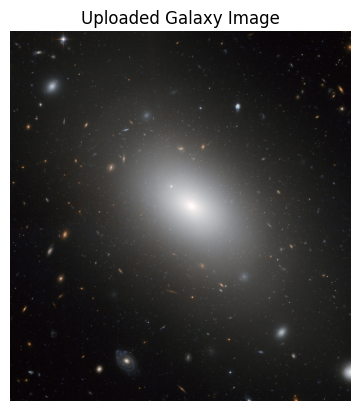

NameError: name 'model' is not defined

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

classes = ["Elliptical", "Spiral", "Irregular"]

# Get image path
img_path = list(uploaded.keys())[0]

# Load and show image
image = Image.open(img_path)
plt.imshow(image)
plt.axis("off")
plt.title("Uploaded Galaxy Image")
plt.show()

# Preprocess for ResNet50
img = np.array(image)
img = cv2.resize(img, (224, 224))
img = tf.keras.applications.resnet50.preprocess_input(img)
img = np.expand_dims(img, axis=0)

# Predict
pred = model.predict(img)
class_idx = np.argmax(pred)
confidence = np.max(pred) * 100

print("🌀 Predicted Class:", classes[class_idx])
print(f"📊 Confidence: {confidence:.2f}%")
